Trilha Acadêmica - Autoencoder
==============================

#### Disciplina: Redes Neurais e Algoritmos Genéticos
#### Professor: Daniel R. Cassar
#### Autora: Sophia Alves

## It's hard to keep a track of year and place!
Nesse trabalho, a proposta é `aprender`. No contexto de redes neurais, há muito o que se aprender, mas dentre as infinitas possibilidades me encanta as redes do tipo `Autoencoders`. 

Essas redes estão agrupadas na aprendizagem não supervisionada, onde não é preciso de rótulos para desenvolver o modelo, sendo uma ferramenta extremamente interessante e condizente com a natureza da maioria dos dados, que são não rotulados. A dimensão de entrada (input) e a de saída (output) é a mesma, e o dado de entrada é exatamente o _target_, já que o modelo tenta fazer a reconstrução do que recebe. O mais interessante dessas redes é a capacidade que elas têm de capturar, com precisão, as características mais importantes dos dados, fornecendo uma versão compactada que obtém a essência das informações do _input_ capaz de o reconstruir com base nessas informações. Os autoencoders também são considerados uma técnica de redução de dimensionalidade, capazes de realizar transformações não lineares no processo de redução de dimensão [1]. Vamos entender melhor as características desse fascinante grupo de redes neurais!

### Autoencoders: entendendo mais sobre eles
Como já explicado brevemente acima, os autoencoders são redes de aprendizado não supervisionado, em que o grande desafio da rede é aprender a reconstruir a informação de entrada detendo uma quantidade menor de entrada que o existente no _input_. Isso é uma característica que os diferencia de redes do tipo _MultiLayer Perceptron (MLP)_, pois a saída em cada em cada uma delas é diferente, de modo que as MLPs constroem as camadas e devolvem um resultado para um problema de regressão ou classificação a ser resolvido, enquanto os _autoencoders_ procuram reconstruir o _input_ com uma menor quantidade de informações. 

<figure style="text-align: center;">
  <img src="https://media.datacamp.com/legacy/v1702635542/image1_e13b38ea2e.png" width="35%" />
  <img src="https://www.dtreg.com/uploaded/pageimg/MLFNwithWeights.jpg" width="55%" />
  <figcaption><i>Figura 1: Comparativo entre o modelo de redes de autoencoder (esquerda) e MLP (direita). Visualmente, é evidente a diferença na arquitetura e intuito de construção das duas redes.</i></figcaption>
</figure>

Como podemos observar na figura esquerda, o autoencoder recebe os dados de entrada, e cada camada seguinte conta com uma menor quantidade de dados (redução da dimensão) que a anterior, forçando o modelo a fazer e realmente __aprender__ representações mais compactas dos dados, induzindo o aprendizado e evitando que o modelo apenas decore as informações. A arquitetura dos autoencoders conta com três partes principais: _encoder_, espaço latente e _decoder_, em que o conjunto delas forma o formato conhecido de ampulheta dos _autoencoders_, dado a simetria das partes de compressão e descompressão com uma parte de menor tamanho que separa essas duas partes, o que chamamos de gargalo (_bottleneck_) da rede. Formalmente, o gargalo é o chamado espaço latente e ele contém as informações mais compactadas da rede, sendo ele que impõe que ela realmente aprenda e consiga realizar a reconstrução. 

<div align="center">
  <img src="https://lilianweng.github.io/posts/2018-08-12-vae/autoencoder-architecture.png" width="500">
</div>


Explicando melhor cada parte do autoencoder [4]: 

- Encoder: parte da rede responsável por compactar os dados de entrada, preservando as informações mais relevantes. Tem início com os dados de _input_, que sofrem redução da dimensão enquanto passam pelas camadas ocultas, até chegar na camada de mínima dimensão: o espaço latente. Aqui termina a parte _encoder_ e o processo foi conduzido de forma a manter as informações mais relevantes dos dados, respeitando o tamanho da dimensão do espaço latente estabelecida como hiperparâmetro. Matematicamente, o _encoder_ consiste numa função _encoder_ $f(x)$, que serve como redutora de dimensionalidade e como ponto de partida para a ação do _decoder_.
- Espaço latente: camada de menor dimensionalidade. Contém as informações mais relevantes que o modelo aprendeu e rotulou como necessárias para a reconstrução da informação de entrada. Seguindo o raciocínio matemático, seria o $h = f(x)$ como o aprendido pelo modelo e presente no espaço latente. 
- Decoder: parte da rede responsável por fazer a reconstrução da informação de entrada a partir dos dados presentes no espaço latente, aplicando g(h) = x. É esperado que a reconstrução não seja exatamente igual ao _input_, apesar de esse ser o ideal, mas isso é lógico devido à pouca quantidade de informação na etapa anterior, que prioriza apenas as partes mais importantes para a reconstrução. 

Para entendermos melhor como os autoencoders funcionam, vamos desenvolver uma rede desse tipo utilizando o dataset _Fetch Olivetti Faces_, importado diretamente do _scikit learn datasets_ e creditando o _AT&T Laboratories Cambridge_ [2], responsável por fazer e disponibilizar as imagens. O banco de dados se consiste em 400 imagens em preto e branco de 40 pessoas (10 de cada), em que cada uma delas mostra a face das pessoas e suas diferentes expressões faciais. O intuito é desenvolver uma rede _autoencoder_ que consiga fazer a reconstrução dos rostos das imagens de entrada, tanto numa imagem original quanto numa com ruído, consistindo num _Denoising Autoencoder_, e, por fim, realizar interpolação entre imagens de duas pessoas diferentes. Nas seções seguintes, iremos explorar cada parte dos autoencoders, desenvolvendo uma rede desse tipo utilizando a biblioteca PyTorch e analisando cada tópico do assunto e como ele se comporta com as informações do dataset trabalhado. 

## Obtendo as imagens do dataset

Iremos importar o dataset diretamente do módulo de datasets do _scikit learn_ e separar em imagens e target, de acordo com o descrito na documentação do dataset [2]. Acima foi descrito que o _input_ é exatamente o target, mas essa separação só foi feita para fins de visualização, já que o _target_ no dataset se refere ao número da pessoa associada nos dados. Então __images__ retorna uma matriz 64x64 das imagens de cada rosto e __target__, a identificação da pessoa. 

In [1]:
#Importando as bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces # Dataset utilizado
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

Total de imagens: 400
Tamanho de cada imagem: 64x64 pixels


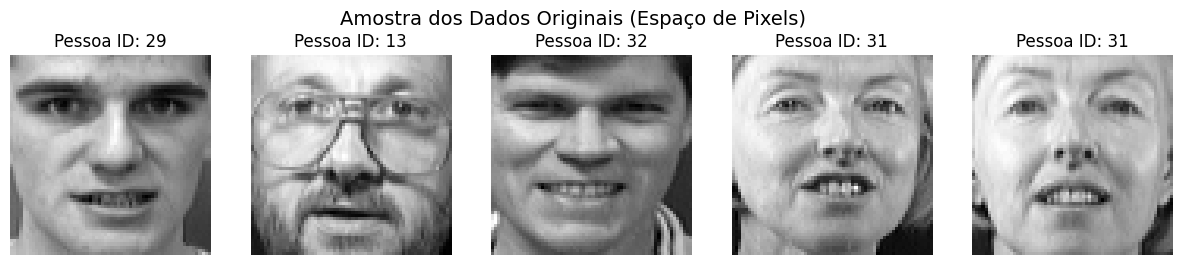

In [2]:
faces_data = fetch_olivetti_faces(shuffle=True, random_state=37)

# 'imagens' contém as matrizes 64x64 de cada rosto
imagens = faces_data.images 

# 'targets' contém o identificador da pessoa (de 0 a 39)
targets = faces_data.target 

print(f"Total de imagens: {imagens.shape[0]}")
print(f"Tamanho de cada imagem: {imagens.shape[1]}x{imagens.shape[2]} pixels")

# 2. Plotando as primeiras 5 imagens para visualização no Notebook
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(imagens[i], cmap='gray') 
    ax.set_title(f"Pessoa ID: {targets[i]}")
    ax.axis('off')
    
plt.suptitle("Amostra dos Dados Originais (Espaço de Pixels)", fontsize=14)
plt.show()

É de grande importância comentar que as _features_ do problema já estão normalizadas. Isso significa que os pixels assumem valores de 0 a 1 e não precisamos nos preocupar com a normalização dos dados de pixel das imagens. 

Para que apliquemos os dados no _autoencoder_, eles precisam ser achatados para vetores unidimensionais, ao invés de matrizes de 64x64 pixels. Contudo, o dataset também já vem organizado com os vetores achatados, então a dimensão também não é um problema. 

### Criando nosso próprio objeto Dataset
É interessante fazermos um objeto Dataset personalizado para armazenar os dados e suas características. Isso está descrito na documentação do PyTorch [5] e altamente recomendado para melhor atender às necessidades de cada modelo, já que o PyTorch é bem sensível ao formato dos dados. Como iremos fazer o _Denoising Autoencoder_ e este exige a adição de um fator de ruído, elaborar um objeto próprio para nossos dados engloba tudo o que for preciso para o trabalho. 

Criamos a classe OlivettiDataset e importamos as configurações do módulo Dataset do PyTorch, com _init_, _len_ e _get_item_. O fator de ruído (noise_factor) foi adicionado e estabeleceu-se uma condição para que os pixels estejam no intervlao de 0 a 1 mesmo com o ruído. O método _unsqueeze_ foi utilizado para adicionar uma dimensão nos dados, especificamente na posição 1, correspondente ao canal, servindo para indicar intensidades no RGB. Como o autoencoder desenvolvido tem camadas lineares, eles não precisam disso e serão achatados de toda forma, mas a aplicação do método torna o código útil no caso de autoencoders convolucionais e também ajudam no pleno funcionamento da função `imshow`do matplot. 

In [3]:
class OlivettiDataset(Dataset): 
    def __init__(self, noise_factor=0.0):
        data = fetch_olivetti_faces(shuffle=True, random_state=37) 
        self.images = torch.tensor(data.images).unsqueeze(1) #adiciona uma dimensão no canal 
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx): # idx = index
        clean = self.images[idx]
        if self.noise_factor > 0:
            noise = torch.randn_like(clean) * self.noise_factor
            noisy = torch.clamp(clean + noise, 0., 1.)
            return noisy, clean  # input corrompido, target limpo
        return clean, clean      # autoencoder normal

In [4]:
dataset = OlivettiDataset()
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Pega um batch e verifica
input_batch, target_batch = next(iter(loader))
print("Shape do input:", input_batch.shape)
print("Shape do target:", target_batch.shape)
print("Valores min/max:", input_batch.min().item(), input_batch.max().item())


Shape do input: torch.Size([32, 1, 64, 64])
Shape do target: torch.Size([32, 1, 64, 64])
Valores min/max: 0.012396694160997868 0.9710744023323059


### Desenvolvendo a arquitetura da rede 
O autoencoder desenvolvido nesse trabalho foi construído com camadas lineares e aplicação da ReLU como parte não linear. A partir disso, definiu-se o `encoder` e o `decoder`, e na última camada do decoder foi feito o uso da função Sigmoid, para garantir valores entre 0 e 1, necessários para a devida comparação da função de perda com os valores originais. O código foi inspirado no contido na referência [10] e [11].

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, dimensao_entrada, dimensao_camadas_ocultas, dimensao_latente):
        super().__init__()
    
        arquitetura_encoder = []
        dimensao_encoder = dimensao_entrada
         
        for i in dimensao_camadas_ocultas: 
            arquitetura_encoder.append(nn.Linear(dimensao_encoder, i))
            arquitetura_encoder.append(nn.ReLU())
            dimensao_encoder = i
        arquitetura_encoder.append(nn.Linear(dimensao_encoder,dimensao_latente))
    
        self.encoder = nn.Sequential(*arquitetura_encoder)
    
        arquitetura_decoder = []
        dimensao_decoder = dimensao_latente 
         
        for i in reversed(dimensao_camadas_ocultas):
            arquitetura_decoder.append(nn.Linear(dimensao_decoder,i))
            arquitetura_decoder.append(nn.ReLU())
            dimensao_decoder = i
        arquitetura_decoder.append(nn.Linear(dimensao_decoder,dimensao_entrada))
        arquitetura_decoder.append((nn.Sigmoid()))
    
        self.decoder = nn.Sequential(*arquitetura_decoder)  

    def forward(self,x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Os autoencoders contam com 4 hiperparâmetros [7]:

- Número de camadas(1) /número de neurônios (dimensão) por camada (2): definida de forma a manter a simetria do modelo, começando com 4096 e diminuindo até chegar à dimensão do espaço latente de 64. Após isso, a dimensão aumenta até retornar a 4096.
- Dimensão do espaço latente
- Função de perda

Como os dados trabalhados têm 4096 dimensões (as imagens têm 64 por 64 pixels), definimos o modelo com input de 4096 dados, seguindo com duas camadas de 1024 e 256, até chegarmos no espaço latente com 64 dimensões. Comparando com o valor original de dimensões, 64 realmente é muito pouco e exige um grande aprendizado do modelo, mas é um valor que funciona bem e é comumente usado na literatura [6]. Abaixo iremos comparar com valores do espaço latente de 32 e 128 dimensões. 

A função de perda escolhida foi o erro quadrático médio (MSE), por ser a mais utilizada na literatura e também manter os valores entre 0 e 1, mas a BCE (perda de entropia cruzada) também poderia ser utilizada, já que também deixa os dados no intervalo definido. Um adendo à BCE é que ela é sensível a valores exatos de 0 e 1, mas isso não deve ser uma grande preocupação dado que os dados são reais.

Por fim, o otimizador escolhido foi o Adam, pois ele mostrou ser o melhor a ser aplicado em redes neurais, juntamente com os valores de taxa de aprendizado e decaimento de peso [8].

In [6]:
modelo_autoencoder = AutoEncoder(4096,[1024,256], 64)

perda = nn.MSELoss()
taxa_de_aprendizado = 1e-3
weight_decay = 1e-5

otimizador = torch.optim.Adam(modelo_autoencoder.parameters(), lr=taxa_de_aprendizado,weight_decay=weight_decay)

Agora vamos fazer o treino do modelo, com lotes de tamanho 32 e 100 épocas. Todo o processo de treinamento da rede seguiu os 5 momentos: _forward pass_, _loss_, _zeragem do gradiente_, _backpropagation_ e atualização dos hiperparâmetros. A cada época múltipla de 10 foi mostrada a sua perda e o histórica da perda foi mostrada no gráfico. Com isso, temos noção de como o modelo está evoluindo e aprendendo. É interessante citar que os valores de X_lote e y_lote foram achatados (uma dimensão) para que o PyTorch não acuse problemas de dimensão.

Época 0 | Perda: 0.024338
Época 10 | Perda: 0.016124
Época 20 | Perda: 0.012246
Época 30 | Perda: 0.012124
Época 40 | Perda: 0.010414
Época 50 | Perda: 0.010514
Época 60 | Perda: 0.009543
Época 70 | Perda: 0.008747
Época 80 | Perda: 0.008351
Época 90 | Perda: 0.008371


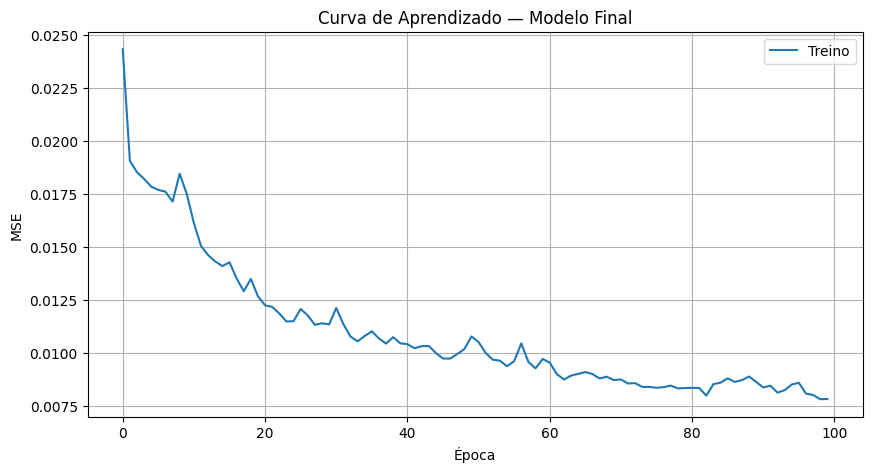

In [7]:
historico_treino = []

for epoca in range(100):
    modelo_autoencoder.train()
    perda_epoca = 0 
    for X_lote, y_lote in loader:
        X_lote = X_lote.view(X_lote.size(0), -1)  # flatten: (batch, 1, 64, 64) → (batch, 4096)
        y_lote = y_lote.view(y_lote.size(0), -1) #achata para nao dar erro de dimensao
        
        otimizador.zero_grad()
        y_pred = modelo_autoencoder(X_lote)
        loss = perda(y_pred, y_lote)
        loss.backward()
        otimizador.step()

        perda_epoca += loss.item()

    perda_media = perda_epoca / len(loader)
        
    historico_treino.append(perda_media)
    
    if epoca % 10 == 0:
        print(f"Época {epoca} | Perda: {perda_media:.6f}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(historico_treino, label="Treino")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de Aprendizado — Modelo Final")
plt.legend()
plt.grid(True)
plt.show()

Agora o modelo irá fazer a reconstrução de imagens. Iremos pegar um X do lote, achatá-lo, passá-lo pelo _autoencoder_ e por fim mostrar o resultado da reconstrução comparado com a imagem original. 

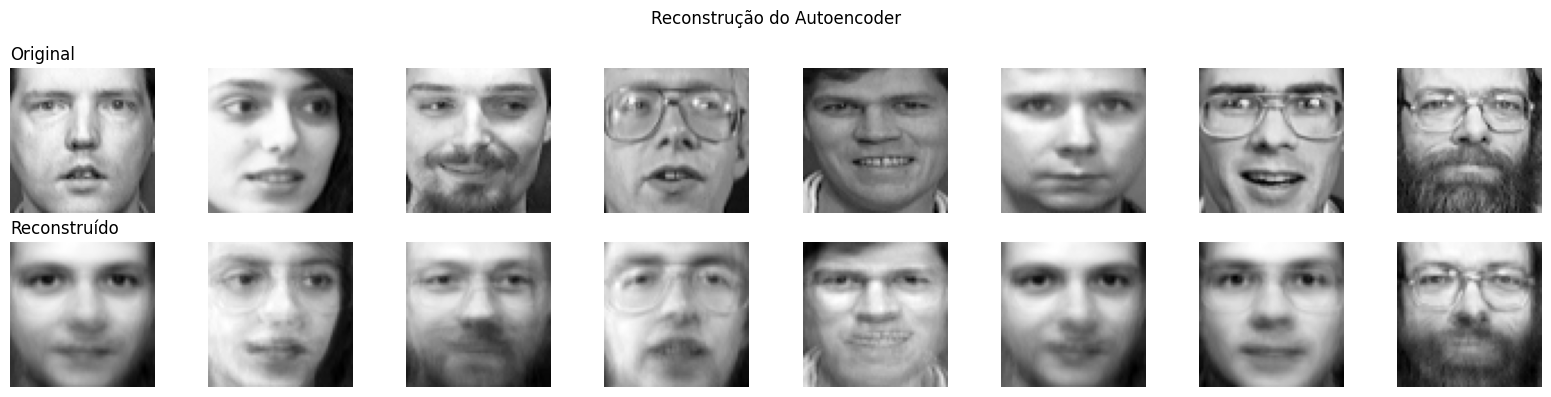

In [8]:
modelo_autoencoder.eval()
with torch.no_grad():
    X_lote, _ = next(iter(loader)) # pega um batch do loader
    X_flat = X_lote.view(X_lote.size(0), -1)
    
    reconstruido = modelo_autoencoder(X_flat)
    reconstruido = reconstruido.view(-1, 1, 64, 64) # volta para o formato de imagem (batch, 1, 64, 64)

# plota 8 pares original vs reconstruído
n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))

for i in range(n):
    # original
    axes[0, i].imshow(X_lote[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', loc='left')
    
    # reconstruído
    axes[1, i].imshow(reconstruido[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstruído', loc='left')

plt.suptitle('Reconstrução do Autoencoder')
plt.tight_layout()
plt.show()

Obtemos um resultado muito interessante! 
O autoencoder fez a reconstrução das imagens de entrada, mas se analisarmos cuidadosamente veremos que elas não são idênticas, o que era esperado e já foi discutido nas seções acima. O autoencoder não consegue copiar a imagem de entrada pois lhe falta informações suficientes para isso. 

A rede conseguiu extrair bem as características mais superficiais, mas não conseguiu reproduzir tão bem características como expressão facial, como sorriso, ou detalhes, como óculos. De modo geral, o modelo aprendeu a reproduzir uma face média, mas não consegue atrelar detalhes suficientes devido à falta de informação.

### E se mudarmos a dimensão do espaço latente para 32 (menos) e 128 (mais)?


In [9]:
#Para dimensão do espaço latente = 32:
modelo_autoencoder32 = AutoEncoder(4096,[1024,256], 32)
otimizador32 = torch.optim.Adam(modelo_autoencoder32.parameters(), lr=taxa_de_aprendizado,weight_decay=weight_decay)

for epoca in range(100):
    modelo_autoencoder32.train()
    perda_epoca32 = 0 
    for X_lote32, y_lote32 in loader:
        X_lote32 = X_lote32.view(X_lote32.size(0), -1)  # flatten: (batch, 1, 64, 64) - (batch, 4096)
        y_lote32 = y_lote32.view(y_lote32.size(0), -1) #achata para nao dar erro de dimensao
        
        otimizador32.zero_grad()
        y_pred32 = modelo_autoencoder32(X_lote32)
        loss32 = perda(y_pred32, y_lote32)
        loss32.backward()
        otimizador32.step()

        perda_epoca32 += loss32.item()

    perda_media32 = perda_epoca32 / len(loader)
    if epoca % 10 == 0:
        print(f"Época {epoca} | Perda: {perda_media32:.6f}")

Época 0 | Perda: 0.023384
Época 10 | Perda: 0.014543
Época 20 | Perda: 0.012509
Época 30 | Perda: 0.010941
Época 40 | Perda: 0.010456
Época 50 | Perda: 0.009848
Época 60 | Perda: 0.008872
Época 70 | Perda: 0.008695
Época 80 | Perda: 0.007757
Época 90 | Perda: 0.007205


In [10]:
#Para dimensão do espaço latente = 128:
modelo_autoencoder128 = AutoEncoder(4096,[1024,256], 128)
otimizador128 = torch.optim.Adam(modelo_autoencoder128.parameters(), lr=taxa_de_aprendizado, weight_decay=weight_decay)

for epoca in range(100):
    modelo_autoencoder128.train()
    perda_epoca128 = 0 
    
    for X_lote128, y_lote128 in loader:
        X_lote128 = X_lote128.view(X_lote128.size(0), -1)  # flatten: (batch, 1, 64, 64) → (batch, 4096)
        y_lote128 = y_lote128.view(y_lote128.size(0), -1) # achata para nao dar erro de dimensao
        
        otimizador128.zero_grad()
        y_pred128 = modelo_autoencoder128(X_lote128)
        loss128 = perda(y_pred128, y_lote128)
        loss128.backward()
        otimizador128.step()

        perda_epoca128 += loss128.item()

    perda_media128 = perda_epoca128 / len(loader)
    
    if epoca % 10 == 0:
        print(f"Época {epoca} | Perda: {perda_media128:.6f}")

Época 0 | Perda: 0.023722
Época 10 | Perda: 0.014512
Época 20 | Perda: 0.011648
Época 30 | Perda: 0.010314
Época 40 | Perda: 0.009786
Época 50 | Perda: 0.009440
Época 60 | Perda: 0.008421
Época 70 | Perda: 0.008457
Época 80 | Perda: 0.007935
Época 90 | Perda: 0.007931


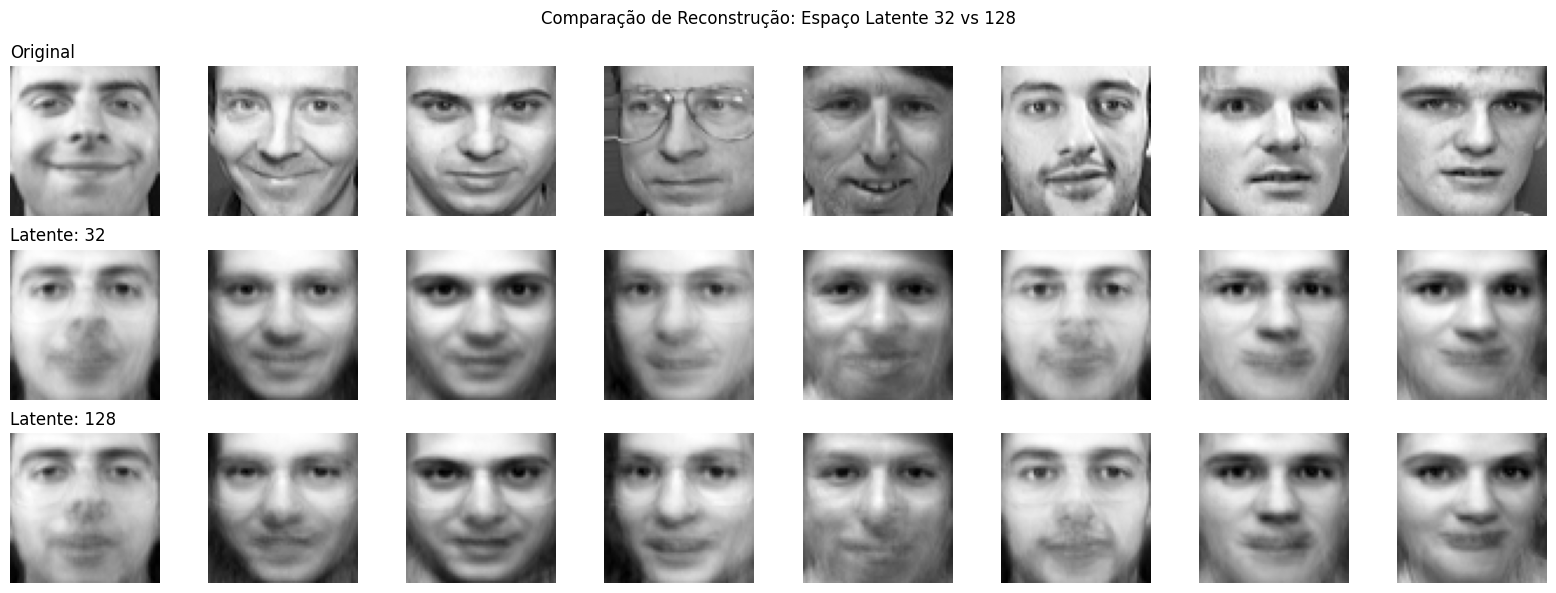

In [11]:
modelo_autoencoder32.eval()
modelo_autoencoder128.eval()

with torch.no_grad():
    X_lote, _ = next(iter(loader)) #mesmo batch para os dois
    X_flat = X_lote.view(X_lote.size(0), -1) # Achata a imagem
    
    reconstruido32 = modelo_autoencoder32(X_flat)
    reconstruido32 = reconstruido32.view(-1, 1, 64, 64) 

    reconstruido128 = modelo_autoencoder128(X_flat)
    reconstruido128 = reconstruido128.view(-1, 1, 64, 64) 

n = 8
fig, axes = plt.subplots(3, n, figsize=(16, 6)) 

for i in range(n):
    axes[0, i].imshow(X_lote[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', loc='left')
        
    axes[1, i].imshow(reconstruido32[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Latente: 32', loc='left')

    axes[2, i].imshow(reconstruido128[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Latente: 128', loc='left')

plt.suptitle('Comparação de Reconstrução: Espaço Latente 32 vs 128')
plt.tight_layout()
plt.show()

Podemos perceber que o espaço latente de maior dimensão conseguiu aprofundar melhor em algumas características, como óculos e formato do nariz, mas tanto o espaço latente de 32 e quanto o de 128 obtiveram resultados similares. 

### Visualizando os resultados do espaço latente de 64 dimensões 
Para fins de visualização, podemos aplicar as técnicas de redução de dimensionalidade PCA (principal component analysis) e t-SNE (t-distributed Stochastic Neighbor Embedding) para analisar como a rede classificou como informações mais importantes para cada uma das fotos das pessoas. Foi selecionado duas componentes das 64 do espaço latente para mostrar a disposição das dimensões mais importantes para cada imagem do dataset. Obviamente, é um recurso visual um tanto limitado, pois duas dimensões de 64 dimensões consideradas importantes para a rede (espaço latente tem as partes mais informativas) não conseguem dizer muito sobre o autoencoder que desenvolvemos, mas pode entregar algo interessante visivelmente. 

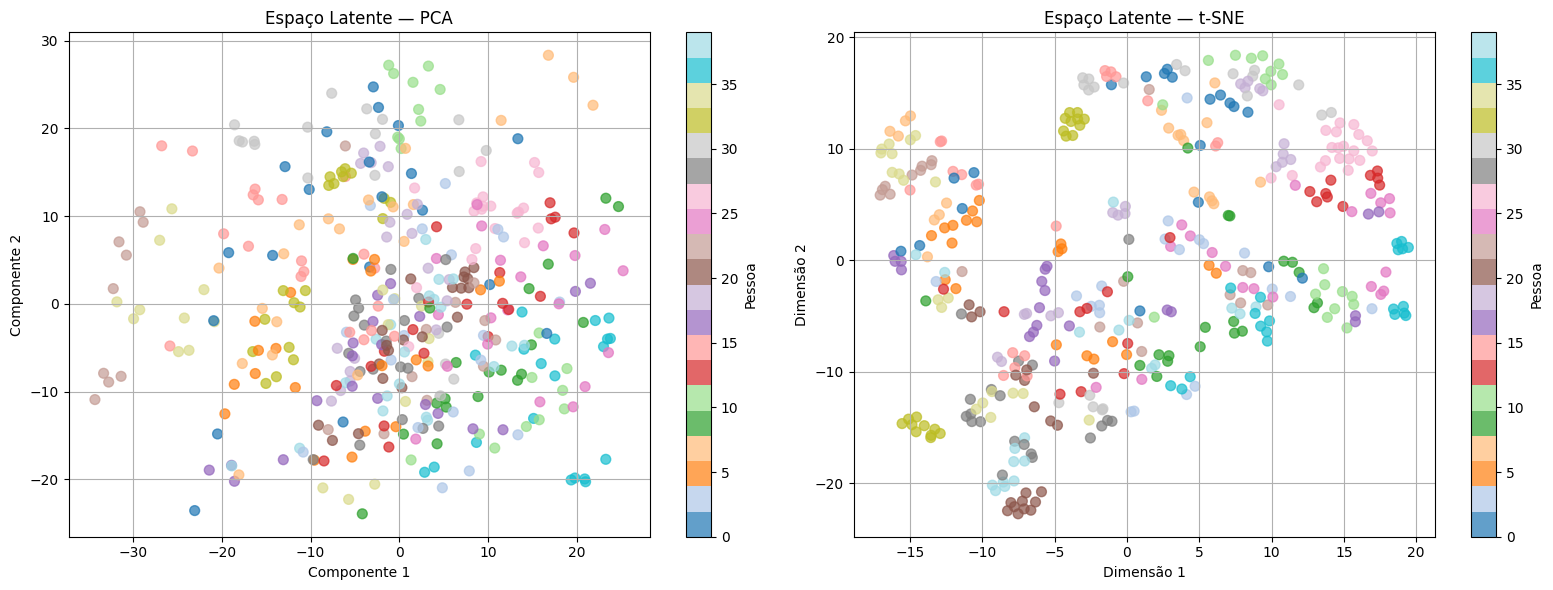

In [12]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# passa todas as imagens pelo encoder
modelo_autoencoder.eval()

with torch.no_grad():
    todas_imagens = dataset.images.reshape(dataset.images.size(0), -1)  # (400, 4096)
    vetores_latentes = modelo_autoencoder.encoder(todas_imagens)      # (400, 64)
    vetores_latentes = vetores_latentes.numpy()

# reduz para 2D com PCA
pca = PCA(n_components=2, random_state=42)
latente_2d_pca = pca.fit_transform(vetores_latentes)

# Reduz para 2D com t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latente_2d_tsne = tsne.fit_transform(vetores_latentes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# gráfico PCA
scatter_pca = axes[0].scatter(latente_2d_pca[:, 0], latente_2d_pca[:, 1], 
                              c=targets, cmap='tab20', alpha=0.7, s=50)
axes[0].set_title('Espaço Latente — PCA')
axes[0].set_xlabel('Componente 1')
axes[0].set_ylabel('Componente 2')
axes[0].grid(True)
fig.colorbar(scatter_pca, ax=axes[0], label='Pessoa')

# gráfico t-SNE
scatter_tsne = axes[1].scatter(latente_2d_tsne[:, 0], latente_2d_tsne[:, 1], 
                               c=targets, cmap='tab20', alpha=0.7, s=50)
axes[1].set_title('Espaço Latente — t-SNE')
axes[1].set_xlabel('Dimensão 1')
axes[1].set_ylabel('Dimensão 2')
axes[1].grid(True)
fig.colorbar(scatter_tsne, ax=axes[1], label='Pessoa') 

plt.tight_layout()
plt.show()

Levando em conta o que foi dito acima, ainda é possível retirar informações das representações do espaço latente. No caso, os pontos de mesma cor (mesma pessoa) no gráfico do PCA ficaram bem espalhados e longe um do outro, enquanto o t-SNE conseguiu agrupar melhor os grupos, conseguindo capturar duas dimensões de maior importância para cada pessoa. Isso tem relação com a natureza de cada técnica, já que o PCA leva em conta que as relações são lineares, enquanto o t-SNE preserva vizinhanças locais de forma não-linear, sendo mais adequado para estruturas complexas como o espaço latente, que não são lineares. 

### Agora o denoising!
Vamos aplicar o denoising autoencoder (DAE), cujo trabalho é reconstruir uma imagem com ruído. Anteriormente definimos o _noise_factor_ no objeto do datset, e agora vamos usá-lo. O fator de ruído altera os valores dos vetores das imagens, sendo o ruído gaussiano o escolhido. Para garantir que os pixels permaneçam no intervalo entre 0 e 1 após a adição do ruído, aplicamos o clamp, que corta os valores fora desse intervalo (melhor observado na classe do dataset OlivettiDataset). 

In [13]:
dataset_noise = OlivettiDataset(noise_factor = 0.2)
loader_noise = DataLoader(dataset_noise, batch_size=32, shuffle=True)

# Pega um batch e verifica
input_batch_noise, target_batch_noise = next(iter(loader_noise))
print("Shape do input:", input_batch_noise.shape)
print("Shape do target:", target_batch_noise.shape)
print("Valores min/max:", input_batch_noise.min().item(), input_batch_noise.max().item())


Shape do input: torch.Size([32, 1, 64, 64])
Shape do target: torch.Size([32, 1, 64, 64])
Valores min/max: 0.0 1.0


In [14]:
#Mesmos parâmeetros anteriores, com a diferença da adição do fator de ruído
modelo_autoencoder_noise = AutoEncoder(4096,[1024,256], 64)

perda_noise = nn.MSELoss()
taxa_de_aprendizado = 1e-3
weight_decay = 1e-5

otimizador_noise = torch.optim.Adam(modelo_autoencoder_noise.parameters(), lr=taxa_de_aprendizado,
                                    weight_decay=weight_decay)

Época 0 | Perda: 0.021972
Época 10 | Perda: 0.014137
Época 20 | Perda: 0.012054
Época 30 | Perda: 0.010705
Época 40 | Perda: 0.010403
Época 50 | Perda: 0.009507
Época 60 | Perda: 0.008866
Época 70 | Perda: 0.008835
Época 80 | Perda: 0.008067
Época 90 | Perda: 0.007659


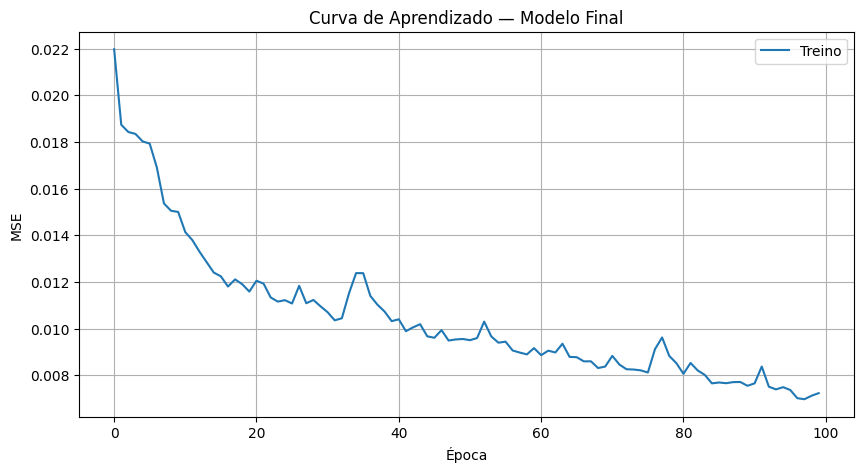

In [15]:
historico_treino_noise= []

for epoca in range(100):
    modelo_autoencoder_noise.train()
    perda_epoca_noise = 0 
    for X_lote_noise, y_lote_noise in loader_noise:
        X_lote_noise = X_lote_noise.view(X_lote_noise.size(0), -1)  # flatten: (batch, 1, 64, 64) - (batch, 4096)
        y_lote_noise = y_lote_noise.view(y_lote_noise.size(0), -1) #achata para nao dar erro de dimensao
        
        otimizador_noise.zero_grad()
        y_pred_noise = modelo_autoencoder_noise(X_lote_noise)
        loss_noise = perda(y_pred_noise, y_lote_noise)
        loss_noise.backward()
        otimizador_noise.step()

        perda_epoca_noise += loss_noise.item()

        perda_media_noise = perda_epoca_noise / len(loader_noise)
        
    historico_treino_noise.append(perda_media_noise)
    
    if epoca % 10 == 0:
        print(f"Época {epoca} | Perda: {perda_media_noise:.6f}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(historico_treino_noise, label="Treino")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de Aprendizado — Modelo Final")
plt.legend()
plt.grid(True)
plt.show()

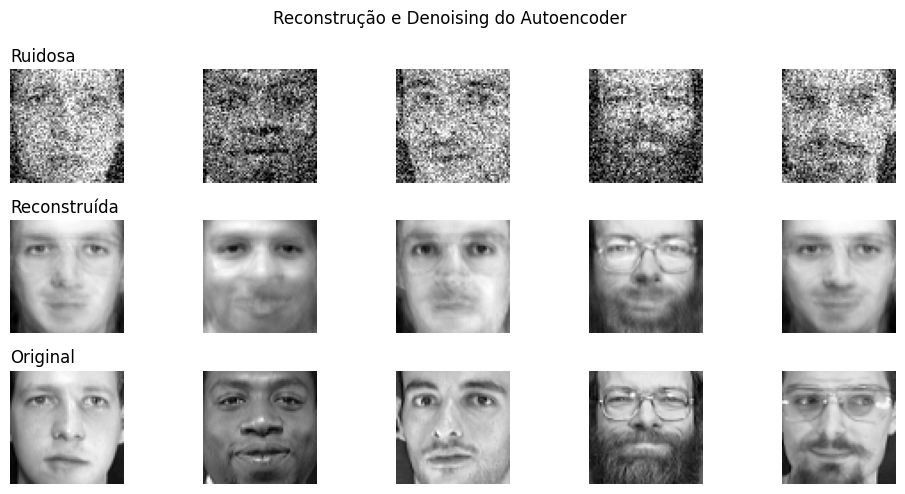

In [16]:
modelo_autoencoder_noise.eval()
with torch.no_grad():
    X_lote_noise, y_lote_noise = next(iter(loader_noise)) # pega um batch do loader
    X_flat_noise = X_lote_noise.view(X_lote_noise.size(0), -1)
    
    reconstruido_denoising = modelo_autoencoder_noise(X_flat_noise)
    reconstruido_denoising = reconstruido_denoising.view(-1, 1, 64, 64) # volta para o formato de imagem (batch, 1, 64, 64)

# plota 8 pares original vs reconstruído
n = 5
fig, axes = plt.subplots(3, n, figsize=(10, 5))

for i in range(n):
    # original
    axes[0, i].imshow(X_lote_noise[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Ruidosa', loc='left')
    
    # reconstruído
    axes[1, i].imshow(reconstruido_denoising[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstruída', loc='left')

    axes[2, i].imshow(y_lote_noise[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Original', loc='left')
    

plt.suptitle('Reconstrução e Denoising do Autoencoder ')
plt.tight_layout()
plt.show()

Mesmo com um ruído alto, pois claramente a imagem não está nada nítida, o autoencoder conseguiu fazer uma boa reconstrução dos rostos das pessoas. Os problemas de conseguir representar bem detalhes ainda persistem, mas o resultado foi excelente dado que o _input_ estava bem ruidoso. Isso é interessante, pois o denoising autoencoder funciona como um regularizador naturalmente, onde o modelo deve realmente aprender as característas relevantes e ignorar o ruído.

### Interpolando as pessoas

Para finalizar esse material, é justo e necessário que investiguemos mais sobre a interpolação em autoencoders. Ela é uma verdadeira amostra do aprendizado da rede e têm um aspecto visual bem instigante. Para que possamos fazer a interpolação no nosso sistema devemos juntar as informações de duas pessoas diferentes e deixar o autoencoder reconstruir o resultante. 

Fazemos isso passando as informações de entrada para o encoder e tomamos os valores dos vetores latentes, que contém as informações do espaço latente, as mais compactas possíveis.

- imagem A $\rightarrow$ encoder $\rightarrow$ vetor latente A (z_A)
- imagem B $\rightarrow$ encoder $\rightarrow$ vetor latente B (z_B)

Depois, fazemos o fluxo de interpolação, tomando os vetores de acordo com o valor de t como diz a fórmula:
$$ z_i = (1-t)\cdot z_A + t \cdot z_B$$

Quando t = 0 temos a imagem A pura e t = 1 temos a imagem B pura. OOs valores intermediários de t fazem uma espécie de ponderamento nos dados de cada uma das imagens. Após isso, geramos N pontos interpolados passando o z_i pelo decoder. 

Para a interpolação, sorteamos duas pessoas aleatórias, nos certificando que elas são diferentes, e passamos elas duas pelo encoder. Depois, realizamos a interpolação pela fórmula mostrada acima e seguimos com a plotagem dessas imagens interpoladas. 

In [17]:
import random as rd

rd.seed(28)

pessoa_A = rd.randint(0, 39)
pessoa_B = rd.randint(0, 39)

while pessoa_B == pessoa_A:
    pessoa_B = rd.randint(0, 39)

idx_A = pessoa_A * 10
idx_B = pessoa_B * 10

pessoa A sorteada: 7 | idx_A: 70
pessoa B sorteada: 8 | idx_A: 80


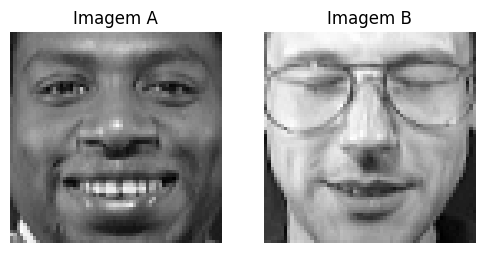

In [21]:
print("pessoa A sorteada:", pessoa_A, "| idx_A:", idx_A)
print("pessoa B sorteada:", pessoa_B, "| idx_A:", idx_B)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(dataset.images[idx_A].squeeze(), cmap='gray')
plt.title('Imagem A')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dataset.images[idx_B].squeeze(), cmap='gray')
plt.title("Imagem B")
plt.axis('off')

plt.show()

Agora vamos passar os dados de cada imagem pelo encoder e realizar a interpolação a partir dos vetores latentes:

In [19]:
modelo_autoencoder.eval()
with torch.no_grad():
    imagem_A = dataset.images[idx_A].reshape(1, -1) 
    imagem_B = dataset.images[idx_B].reshape(1, -1) 
    
    z_A = modelo_autoencoder.encoder(imagem_A).squeeze()  
    z_B = modelo_autoencoder.encoder(imagem_B).squeeze()  

valores_t = np.linspace(0, 1, 10)
imagens_interpoladas = []

with torch.no_grad():
    for t in valores_t:
        z_t = (1 - t) * z_A + t * z_B
        imagem = modelo_autoencoder.decoder(z_t.unsqueeze(0))
        imagem = imagem.view(1, 64, 64)
        imagens_interpoladas.append(imagem)

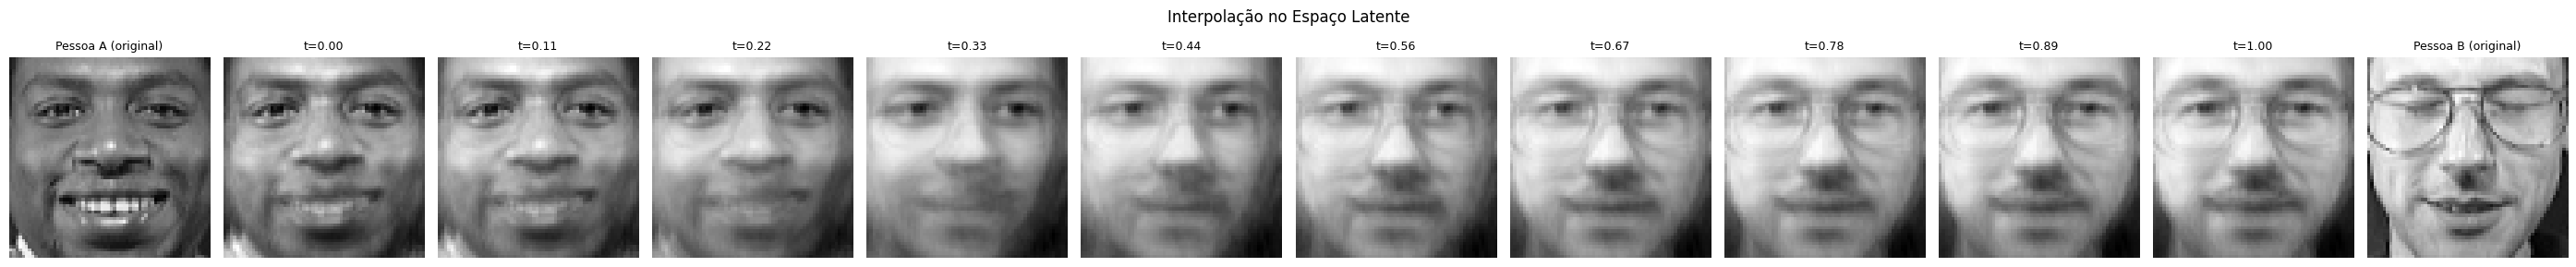

In [20]:
n = len(imagens_interpoladas)
fig, axes = plt.subplots(1, n + 2, figsize=(28, 3))

A = dataset.images[idx_A]
B = dataset.images[idx_B]

# original A na primeira posição
axes[0].imshow(A.squeeze(), cmap='gray')
axes[0].set_title('Pessoa A (original)', fontsize=9)
axes[0].axis('off')

for i in range(n):
    axes[i + 1].imshow(imagens_interpoladas[i].squeeze(), cmap='gray')
    axes[i + 1].axis('off')
    if i == 0:
        axes[i + 1].set_title('t=0.00', fontsize=9)
    elif i == n - 1:
        axes[i + 1].set_title('t=1.00', fontsize=9)
    else:
        axes[i + 1].set_title(f't={valores_t[i]:.2f}', fontsize=9)

# original B na última posição
axes[-1].imshow(B.squeeze(), cmap='gray')
axes[-1].set_title('Pessoa B (original)', fontsize=9)
axes[-1].axis('off')

plt.suptitle('Interpolação no Espaço Latente')
plt.tight_layout()
plt.show()

Vejamos que interessante! 

É possível ver a pessoa A se "transformando" na pessoa B aos poucos, havendo combinação de suas características de acordo com o passar das imagens. É uma aplicação possível dos autoencoders, mas a variedade Variational Autoencoder (VAE) resolve esse problema de forma espetacular, forçando o espaço latente seguir uma distribuição normal e gerando imagens interpoladas mais suaves. Apesar de percebermos que as imagens reconstruídas têm suas falhas e imprecisões já descritas anteriormentes, a interpolação foi muito bem executada pela rede de autoencoder, explicitando que ele conseguiu aprender bastante dos dados mesmo com um espaço pequeno em relação à dimensionalidade dos dados inicias.

## Conclusões
Tendo conhecido a arquitetura e a atividade dos autoencoders, percebemos que eles são ferramentas poderossísimas no campo das redes neurais, especialmente no ramo de aprendizado não supervisionado, mostrando-se eficaz em reconstruir os rostos das pessoas do dataset utilizado, com ou sem a aplicação de ruído na imagem, e ainda na realização de interpolação, gerando novas imagens como combinações das outras. 

Apesar dessas realizações, o modelo desenvolvido não conseguiu reconstruir tão bem detalhes mais específicos, como óculos, sorrisos e expressões, devido à grande compressão dos dados. Além disso, a métrica utilizada (MSE) tende a favorecer reconstruções mais suaves e generalistas, sem atentar muito às especificiddades de cada indivíduo. A comparação entre diferentes espaços latentes mostrou que a compressão induz perda de informação, e um maior espaço latente consegue gerar um output mais fiel e próximo do que deveria ser. O modelo de denoising foi forçado a aprender mais, para entender o que era ruído e o que era informação, mostrando que uma tarefa mais difícil possibilita melhor generalização.

Para melhores desempenhos, existem formas específicas de autoencoders com excelentes desempenhos para tarefas específicas. No caso de identificar e manter detalhes finos, como o óculos, autoencoders convolucionais são mais adequados, ou para fazer interpolações mais suaves e novos rostos, é indicado os autoencoders variacionais. Existem diferentes modelos que conseguem ter melhor desempenho em determinadas áreas, mas, de maneira geral, foi possível entender melhor sobre a arquitetura dos autoencoders, seu modo de funcionamento e aplicações, sendo uma ferramenta excepcional no meio de aprendizado de máquina, principalmente como introdução ao aprendizado não supervisionado.

# Referencias 
[1] DATACAMP. Introduction to Autoencoders. Disponível em: https://www.datacamp.com/pt/tutorial/introduction-to-autoencoders. Acesso em: 11 maio 2026.

[2] SCIKIT-LEARN. sklearn.datasets.fetch_olivetti_faces. Disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html. Acesso em: 11 maio 2026.

[3] GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. Deep Learning: Chapter 14 — Autoencoders. Disponível em: https://www.deeplearningbook.org/contents/autoencoders.html. Acesso em: 11 maio 2026.

[4] WENG, Lilian. From Autoencoder to Beta-VAE. Lil'Log, 2018. Disponível em: https://lilianweng.github.io/posts/2018-08-12-vae/. Acesso em: 11 maio 2026.

[5] PYTORCH. Datasets & DataLoaders. Disponível em: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html. Acesso em: 11 maio 2026.

[6] WHITE, Tom. Understanding and Improving Interpolation in Autoencoders via an Adversarial Regularizer. Disponível em: https://scispace.com/pdf/understanding-and-improving-interpolation-in-autoencoders-47ep6fkc2j.pdf. Acesso em: 11 maio 2026.

[7] HASAN, Syed. Autoencoders: Theory & PyTorch Implementation. Medium, 2023. Disponível em: https://medium.com/@syed_hasan/autoencoders-theory-pytorch-implementation-a2e72f6f7cb7. Acesso em: 11 maio 2026.

[8] ALVES, Sophia. A rota da Neuromante, 2026. 

[9] Claude. Disponível em: <https://claude.ai/chat/507df4ca-eed1-4e2f-8ab8-fb16409c3746>. Acesso em: 11 maio. 2026.

[10] PATRICK LOEBER. Autoencoder In PyTorch - Theory & Implementation. Disponível em: <https://www.youtube.com/watch?v=zp8clK9yCro>. Acesso em: 21 mar. 2025.

‌[11] GEEKSFORGEEKS. Implementing an Autoencoder in PyTorch. Disponível em: <https://www.geeksforgeeks.org/deep-learning/implementing-an-autoencoder-in-pytorch/>.
